In [2]:
from datasets import load_dataset

# Load the Teklia IAM-line dataset
dataset = load_dataset("Teklia/IAM-line", split="train[:200]")

print(f"Loaded {len(dataset)} examples")
print(dataset[0])

README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

Loaded 200 examples
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=L size=2467x128 at 0x12797CA10>, 'text': 'put down a resolution on the subject'}


In [3]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import ImageOps
import torch

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-small-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-small-handwritten")
model.eval()

predictions = []
ground_truths = []

for i, example in enumerate(dataset):
    image = example["image"].convert("RGB")
    image = ImageOps.grayscale(image)
    image = ImageOps.autocontrast(image)
    image = image.convert("RGB")

    pixel_values = processor(images=image, return_tensors="pt").pixel_values

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    ground_truth = example["text"]

    predictions.append(predicted_text)
    ground_truths.append(ground_truth)

    if i % 20 == 0:
        print(f"Processed {i}/200...")

print("Done!")

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Processed 0/200...
Processed 20/200...
Processed 40/200...
Processed 60/200...
Processed 80/200...
Processed 100/200...
Processed 120/200...
Processed 140/200...
Processed 160/200...
Processed 180/200...
Done!


In [4]:
from jiwer import cer, wer

baseline_cer = cer(ground_truths, predictions)
baseline_wer = wer(ground_truths, predictions)

print(f"Baseline CER: {baseline_cer:.2%}")
print(f"Baseline WER: {baseline_wer:.2%}")

Baseline CER: 2.54%
Baseline WER: 6.74%


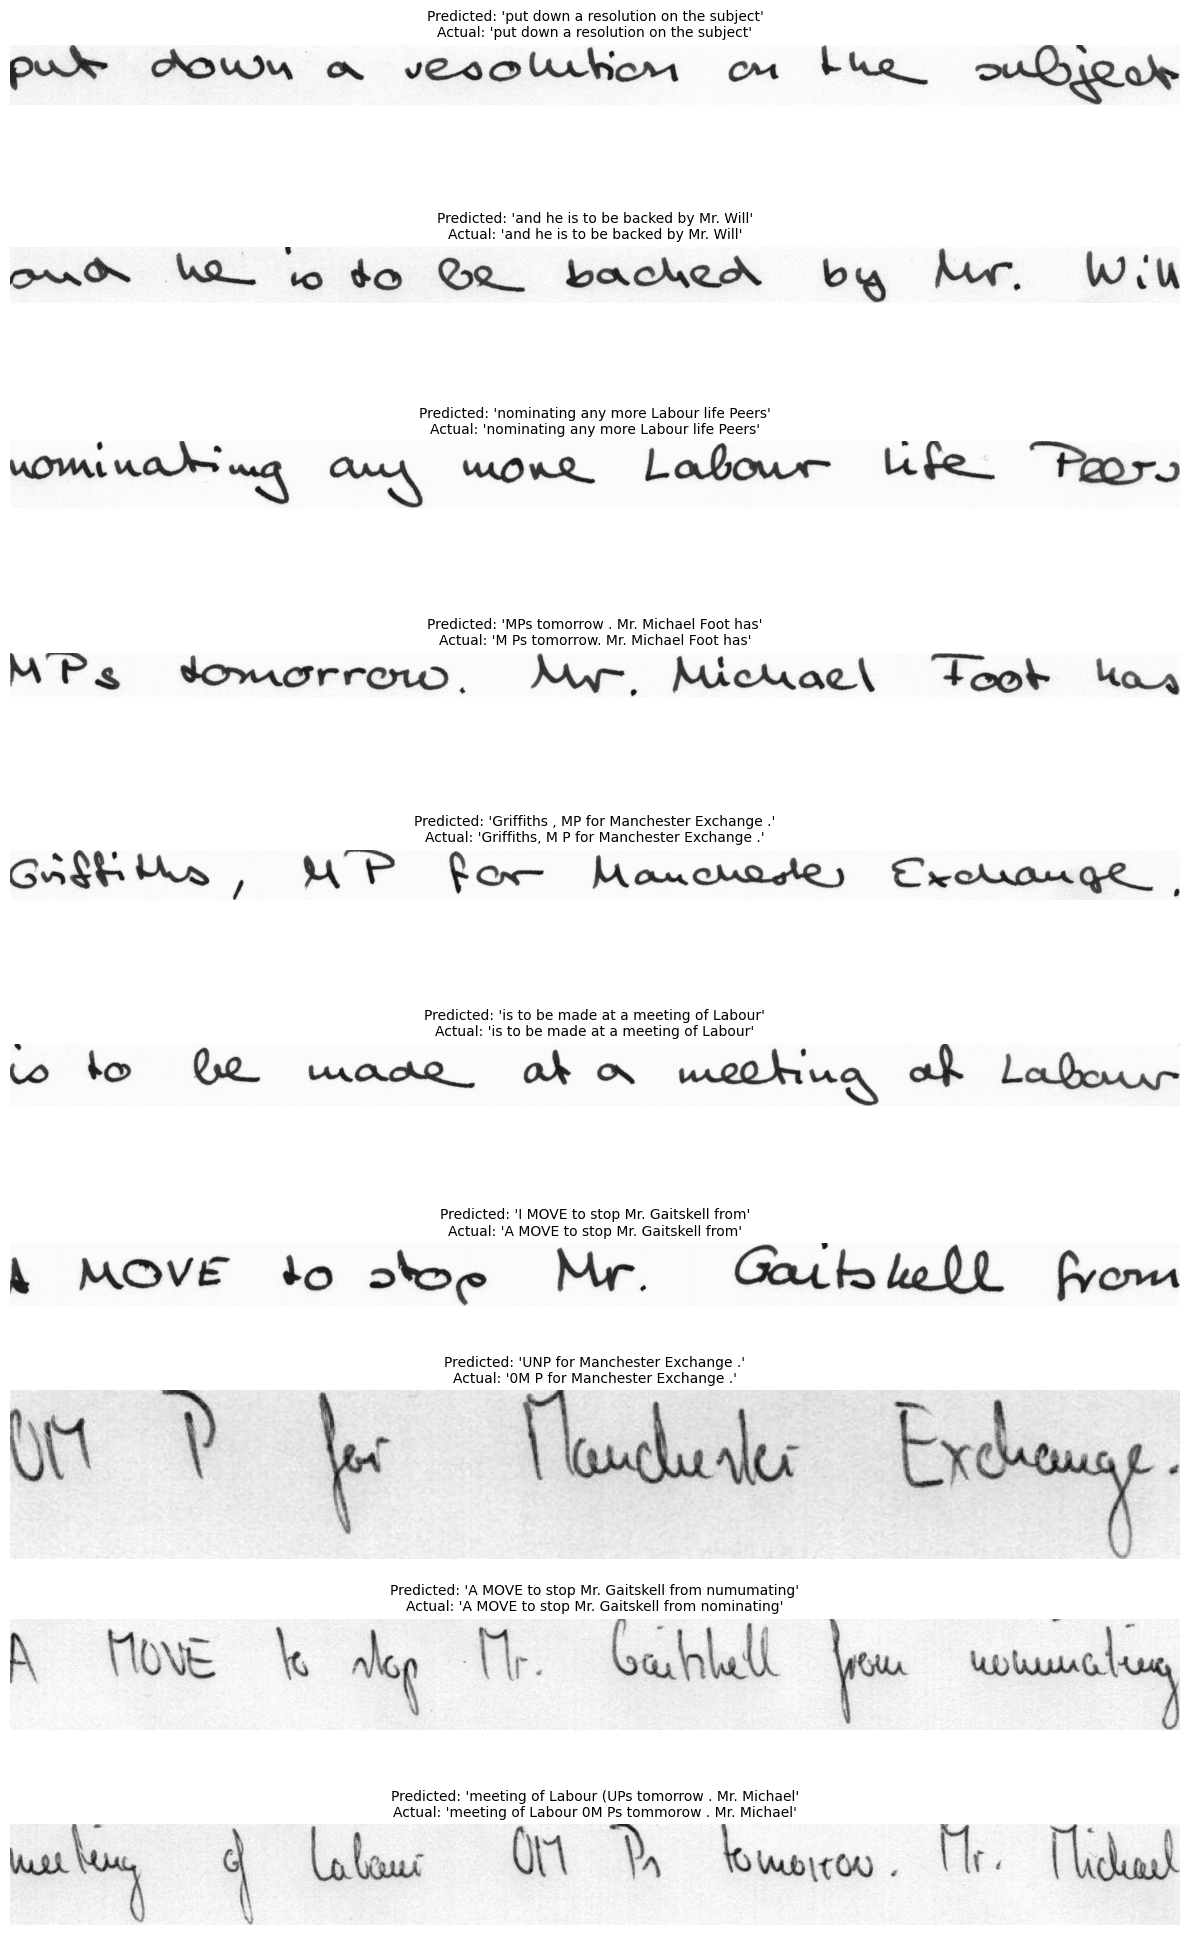

In [5]:
import matplotlib.pyplot as plt

def show_examples(predictions, ground_truths, dataset, n=10):
    fig, axes = plt.subplots(n, 1, figsize=(12, n * 2))
    for i in range(n):
        image = dataset[i]["image"]
        axes[i].imshow(image, cmap="gray")
        axes[i].set_title(
            f"Predicted: '{predictions[i]}'\nActual: '{ground_truths[i]}'",
            fontsize=10
        )
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_examples(predictions, ground_truths, dataset)

## Testing Summary

### Findings
After running on 200 examples, the model achieved a:
- Character error rate of: 2.54%
- Word error rate of: 6.74%

### Struggles
- Short words / abbreviated sequences are harder than long words
- Space/boundary detection between characters is uncertain
- O and U are visually confused in messier handwriting

In [6]:
from jiwer import cer

# Compute per-sample CER
sample_cers = []
for pred, truth in zip(predictions, ground_truths):
    sample_cer = cer(truth, pred)
    sample_cers.append(sample_cer)

# Sort by worst CER
indexed = sorted(enumerate(sample_cers), key=lambda x: x[1], reverse=True)
worst_indices = [i for i, _ in indexed[:30]]

print("Worst 10 samples by CER:")
for i in worst_indices[:10]:
    print(f"  [{i}] CER: {sample_cers[i]:.2%} | Predicted: '{predictions[i]}' | Actual: '{ground_truths[i]}'")

Worst 30 samples by CER:
  [89] CER: 123.08% | Predicted: 'HelpLearn to editCommunity portalRecent changesUpload file' | Actual: 'getting an elected majority in Northern'
  [122] CER: 26.32% | Predicted: '" We must be discussed to do if the' | Actual: '" We want to discuss what to do if the'
  [111] CER: 23.08% | Predicted: 'at Chambers .' | Actual: 'at Chequers .'
  [92] CER: 21.05% | Predicted: 'to O discuss a common course of action . . . .' | Actual: 'to discuss a common course of action .'
  [12] CER: 15.22% | Predicted: 'and he is to be backed by Mr. Hull Crippitz ,' | Actual: 'and he is to be backed by Mr. Will Griffiths ,'
  [116] CER: 13.16% | Predicted: 'British Government gives in his Roy' | Actual: 'British Government gives in to Sir Roy'
  [64] CER: 12.82% | Predicted: 'Since 1958 , 13 Labour life Peers and Peers' | Actual: 'Since 1958 , 13 Labour life Peers and #'
  [26] CER: 12.20% | Predicted: 'which would appear to " pros up " an old .' | Actual: 'which would appear to

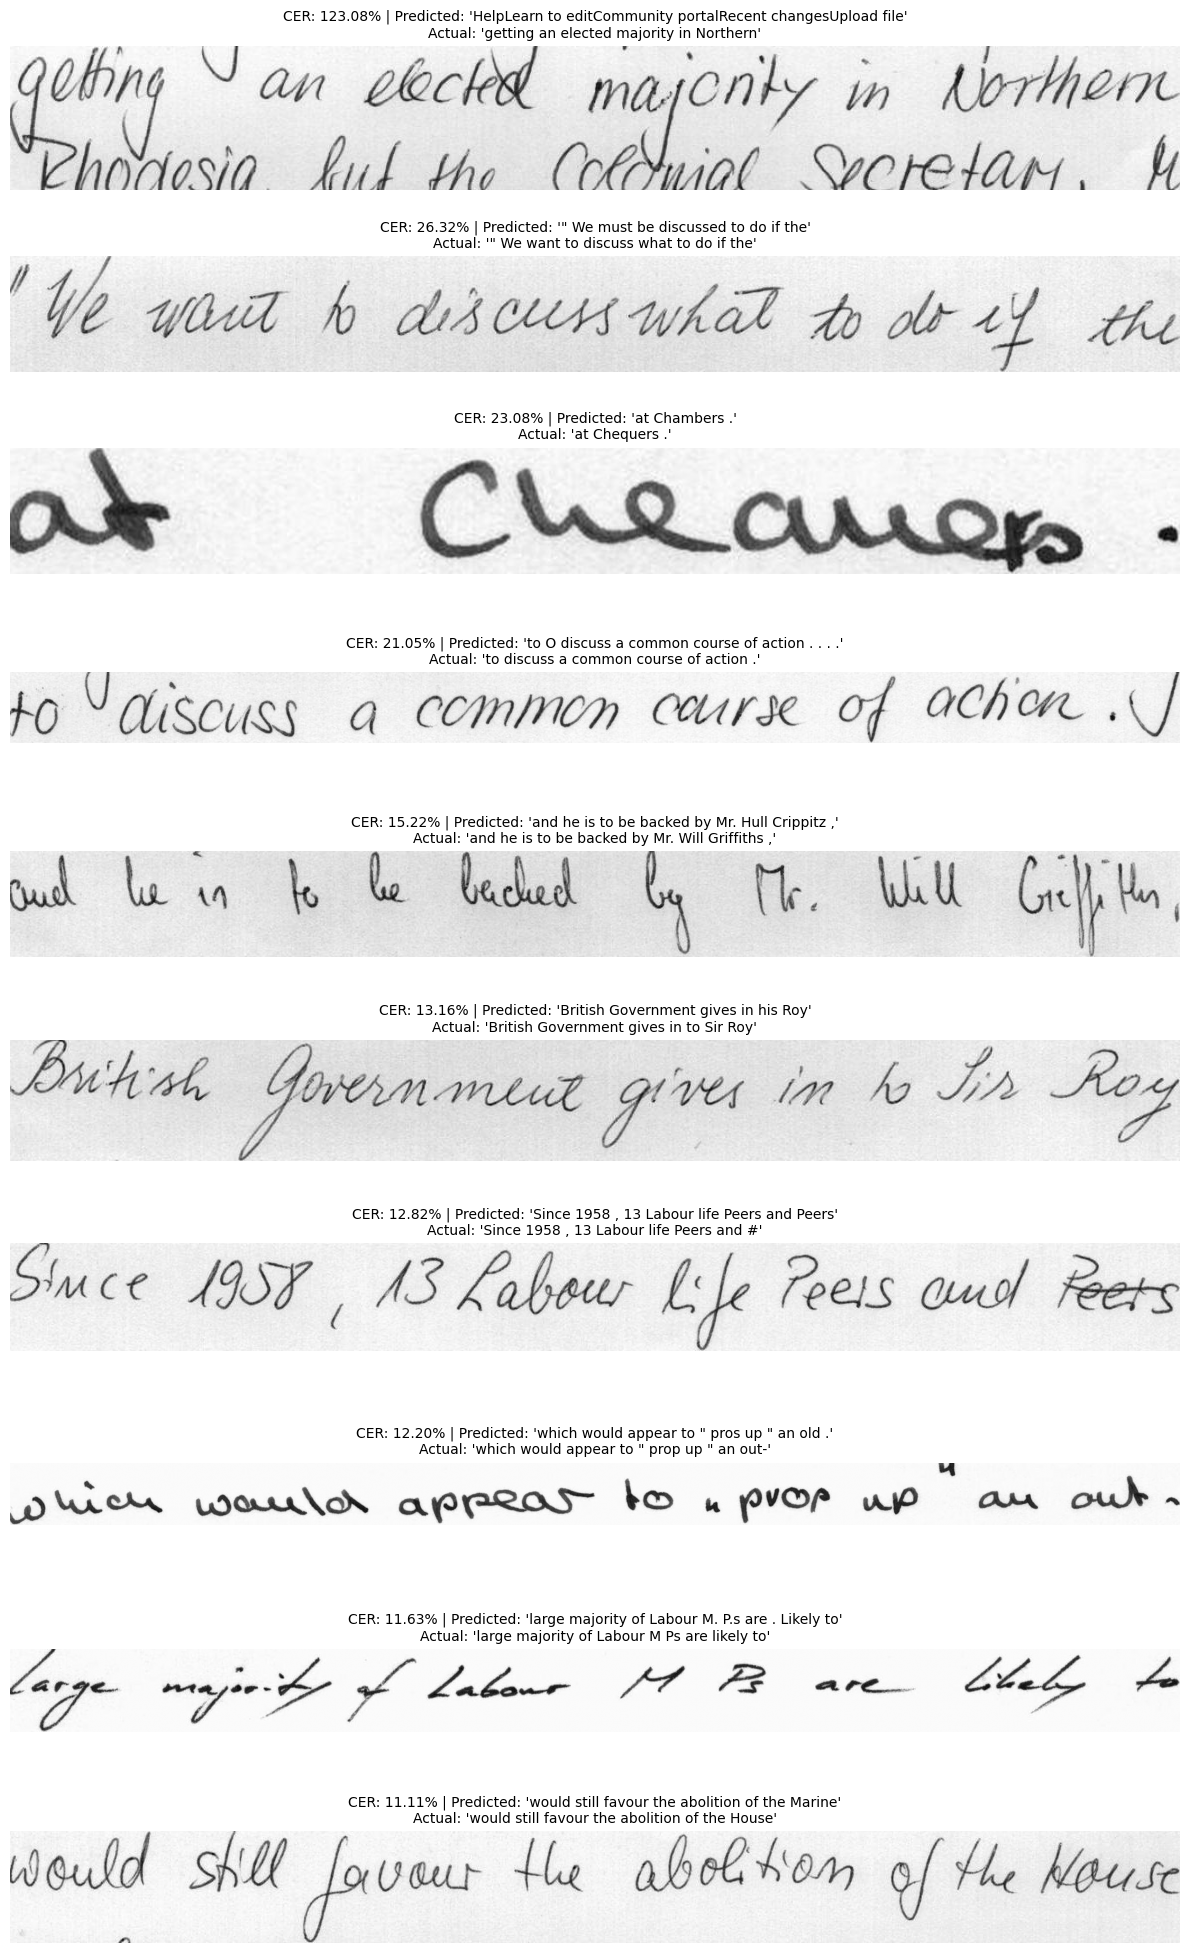

In [7]:
def show_worst(predictions, ground_truths, dataset, worst_indices, n=10):
    fig, axes = plt.subplots(n, 1, figsize=(12, n * 2))
    for plot_i, sample_i in enumerate(worst_indices[:n]):
        image = dataset[sample_i]["image"]
        axes[plot_i].imshow(image, cmap="gray")
        axes[plot_i].set_title(
            f"CER: {sample_cers[sample_i]:.2%} | Predicted: '{predictions[sample_i]}'\nActual: '{ground_truths[sample_i]}'",
            fontsize=10
        )
        axes[plot_i].axis("off")
    plt.tight_layout()
    plt.show()

show_worst(predictions, ground_truths, dataset, worst_indices)

In [8]:
from collections import defaultdict

char_correct = defaultdict(int)
char_total = defaultdict(int)

for pred, truth in zip(predictions, ground_truths):
    for char in truth:
        char_total[char] += 1
        if char in pred:
            char_correct[char] += 1

# Compute accuracy per character
char_accuracy = {
    char: char_correct[char] / char_total[char]
    for char in char_total
    if char_total[char] >= 5  # only show chars with enough samples
}

# Sort by worst accuracy
sorted_chars = sorted(char_accuracy.items(), key=lambda x: x[1])

print("Hardest characters (asc):")
for char, acc in sorted_chars[:15]:
    print(f"  '{char}': {acc:.2%} accuracy ({char_total[char]} samples)")

Hardest characters (lowest accuracy):
  'q': 77.78% accuracy (9 samples)
  ':': 80.00% accuracy (5 samples)
  ')': 83.33% accuracy (6 samples)
  '0': 87.10% accuracy (31 samples)
  '"': 87.50% accuracy (16 samples)
  'j': 90.91% accuracy (11 samples)
  'W': 90.91% accuracy (11 samples)
  'S': 93.55% accuracy (31 samples)
  'G': 94.44% accuracy (18 samples)
  '-': 94.44% accuracy (18 samples)
  'k': 95.56% accuracy (45 samples)
  'H': 96.15% accuracy (26 samples)
  ''': 96.15% accuracy (26 samples)
  'A': 96.30% accuracy (27 samples)
  '.': 96.40% accuracy (111 samples)


In [9]:
import numpy as np

widths = [dataset[i]["image"].size[0] for i in range(len(predictions))]

# Bin into short / medium / long
short = [sample_cers[i] for i, w in enumerate(widths) if w < 1000]
medium = [sample_cers[i] for i, w in enumerate(widths) if 1000 <= w < 2000]
long_ = [sample_cers[i] for i, w in enumerate(widths) if w >= 2000]

print(f"Short images  — avg CER: {np.mean(short):.2%} ({len(short)} samples)")
print(f"Medium images — avg CER: {np.mean(medium):.2%} ({len(medium)} samples)")
print(f"Long images   — avg CER: {np.mean(long_):.2%} ({len(long_)} samples)")

Short images  — avg CER: 2.00% (5 samples)
Medium images — avg CER: 4.38% (82 samples)
Long images   — avg CER: 1.32% (113 samples)


## Error Analysis Summary

### Visual patterns in worst predictions
- Cursive / connected handwriting
- Incomplete or malformed letters

### Hardest character categories
- Punctuation and rare characters
- Visually similar characters (0, S, G)
- Capital letters

### Image length vs error rate
- Medium length lines have highest CER (4.38%)
- Long lines perform best (1.32%)